# Inter-Rater Reliability Analysis using Fleiss' Kappa

This notebook analyzes agreement between three domain experts (Nipun, Chamath, Ruvindu) evaluating LLM-generated planning problems across three quality criteria: MF (Model Fidelity), INV (Invariance), and DIR (Directional).

## Analysis Levels:
1. **Overall Fleiss' Kappa** - Agreement across all 25 samples
2. **Domain-Stratified Kappa** - Agreement within each planning domain
3. **Pairwise Cohen's Kappa** - Agreement between expert pairs

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Step 1: Load Expert Evaluation Data

In [2]:
# Load all three expert CSV files
nipun_df = pd.read_csv('Expert Evaluation Sheet Nipun.csv')
chamath_df = pd.read_csv('Expert Evaluation Sheet chamath.csv')
ruvindu_df = pd.read_csv('Expert Evaluation Sheet ruvindu.csv')

# Clean data - keep only valid rows (first 25 samples)
nipun_df = nipun_df.head(25)
chamath_df = chamath_df.head(25)
ruvindu_df = ruvindu_df.head(25)

# Add expert identifier
nipun_df['Expert'] = 'Nipun'
chamath_df['Expert'] = 'Chamath'
ruvindu_df['Expert'] = 'Ruvindu'

# Extract domain from Plan ID
nipun_df['Domain'] = nipun_df['Plan ID'].str.split(' ').str[0]
chamath_df['Domain'] = chamath_df['Plan ID'].str.split(' ').str[0]
ruvindu_df['Domain'] = ruvindu_df['Plan ID'].str.split(' ').str[0]


print(f"Nipun samples: {len(nipun_df)}")
print(f"Chamath samples: {len(chamath_df)}")
print(f"Ruvindu samples: {len(ruvindu_df)}")
print(f"\nDomains: {nipun_df['Domain'].unique()}")

Nipun samples: 25
Chamath samples: 25
Ruvindu samples: 25

Domains: ['barmen' 'blocksworld' 'floortile' 'grippers' 'storage']


## Step 2: Helper Functions for Kappa Calculation

In [3]:
def calculate_fleiss_kappa_manual(expert_dfs, criterion='MF'):
    """
    Calculate Fleiss' Kappa for a specific criterion across all experts.
    
    Parameters:
        expert_dfs: list of DataFrames [nipun_df, chamath_df, ruvindu_df]
        criterion: 'MF', 'INV', 'DIR', or 'Overall'
    
    Returns:
        kappa: Fleiss' Kappa value
        p_value: Statistical significance
        interpretation: Text interpretation
        categories_table: Aggregated ratings table
    """
    n_items = len(expert_dfs[0])  # 25 planning problems
    n_raters = len(expert_dfs)    # 3 experts
    
    # Create aggregated table for Fleiss' Kappa
    # Rows = items (25 problems), Columns = categories (Pass, Fail)
    categories_table = np.zeros((n_items, 2))
    
    for item_idx in range(n_items):
        for expert_df in expert_dfs:
            # Get judgment for this item
            if criterion == 'Overall':
                # Overall Pass = MF AND INV AND DIR all Pass
                mf = expert_df.iloc[item_idx]['MF (Pass/Fail)'].strip()
                inv_col = 'INV (Pass/Fail)' if 'INV (Pass/Fail)' in expert_df.columns else 'INV (Pass/Fail)'
                dir_col = 'DIR (Pass/Fail)' if 'DIR (Pass/Fail)' in expert_df.columns else 'DIR (Pass/Fail)'
                inv = expert_df.iloc[item_idx][inv_col].strip()
                dir_ = expert_df.iloc[item_idx][dir_col].strip()
                
                judgment = 'Pass' if (mf == 'Pass' and inv == 'Pass' and dir_ == 'Pass') else 'Fail'
            else:
                # Get specific criterion column
                col_name = f'{criterion} (Pass/Fail)'
                judgment = expert_df.iloc[item_idx][col_name].strip()
            
            # Count Pass vs Fail
            if judgment == 'Pass':
                categories_table[item_idx, 0] += 1  # Pass category
            else:
                categories_table[item_idx, 1] += 1  # Fail category
    
    # Calculate Fleiss' Kappa using statsmodels
    kappa = fleiss_kappa(categories_table)
    
    # Calculate p-value (approximate using normal approximation)
    # Standard error for Kappa
    n = n_items * n_raters
    se_kappa = np.sqrt(1 / (n * (n_raters - 1)))
    z_score = kappa / se_kappa
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))  # Two-tailed test
    
    # Interpret Kappa (Landis & Koch 1977)
    if kappa < 0:
        interpretation = "Poor (worse than chance)"
    elif kappa < 0.20:
        interpretation = "Slight"
    elif kappa < 0.40:
        interpretation = "Fair"
    elif kappa < 0.60:
        interpretation = "Moderate"
    elif kappa < 0.80:
        interpretation = "Substantial"
    else:
        interpretation = "Almost Perfect"
    
    return kappa, p_value, interpretation, categories_table


def calculate_cohen_kappa(expert1_df, expert2_df, criterion='MF'):
    """
    Calculate Cohen's Kappa between two experts for a specific criterion.
    
    Parameters:
        expert1_df, expert2_df: DataFrames for two experts
        criterion: 'MF', 'INV', 'DIR', or 'Overall'
    
    Returns:
        kappa: Cohen's Kappa value
        interpretation: Text interpretation
    """
    n_items = len(expert1_df)
    ratings1 = []
    ratings2 = []
    
    for item_idx in range(n_items):
        if criterion == 'Overall':
            # Overall Pass = MF AND INV AND DIR all Pass
            def get_overall(df, idx):
                mf = df.iloc[idx]['MF (Pass/Fail)'].strip()
                inv_col = 'INV (Pass/Fail)' if 'INV (Pass/Fail)' in df.columns else 'INV (Pass/Fail)'
                dir_col = 'DIR (Pass/Fail)' if 'DIR (Pass/Fail)' in df.columns else 'DIR (Pass/Fail)'
                inv = df.iloc[idx][inv_col].strip()
                dir_ = df.iloc[idx][dir_col].strip()
                return 'Pass' if (mf == 'Pass' and inv == 'Pass' and dir_ == 'Pass') else 'Fail'
            
            judgment1 = get_overall(expert1_df, item_idx)
            judgment2 = get_overall(expert2_df, item_idx)
        else:
            col_name = f'{criterion} (Pass/Fail)'
            judgment1 = expert1_df.iloc[item_idx][col_name].strip()
            judgment2 = expert2_df.iloc[item_idx][col_name].strip()
        
        # Convert to binary (0=Fail, 1=Pass)
        ratings1.append(1 if judgment1 == 'Pass' else 0)
        ratings2.append(1 if judgment2 == 'Pass' else 0)
    
    # Calculate Cohen's Kappa
    kappa = cohen_kappa_score(ratings1, ratings2)
    
    # Interpret
    if kappa < 0:
        interpretation = "Poor"
    elif kappa < 0.20:
        interpretation = "Slight"
    elif kappa < 0.40:
        interpretation = "Fair"
    elif kappa < 0.60:
        interpretation = "Moderate"
    elif kappa < 0.80:
        interpretation = "Substantial"
    else:
        interpretation = "Almost Perfect"
    
    return kappa, interpretation


def calculate_domain_kappa(expert_dfs, domain, criterion='MF'):
    """
    Calculate Fleiss' Kappa for a specific domain and criterion.
    
    Parameters:
        expert_dfs: list of DataFrames 
        domain: 'barmen', 'blocksworld', 'floortile', 'grippers', 'storage'
        criterion: 'MF', 'INV', 'DIR'
    
    Returns:
        kappa: Fleiss' Kappa value
        interpretation: Text interpretation
    """
    # Filter to only this domain
    domain_dfs = [df[df['Domain'] == domain].reset_index(drop=True) for df in expert_dfs]
    
    n_items = len(domain_dfs[0])  # Should be 5 samples per domain
    n_raters = len(domain_dfs)
    
    if n_items == 0:
        return None, "No data"
    
    # Create categories table
    categories_table = np.zeros((n_items, 2))
    
    for item_idx in range(n_items):
        for expert_df in domain_dfs:
            col_name = f'{criterion} (Pass/Fail)'
            judgment = expert_df.iloc[item_idx][col_name].strip()
            
            if judgment == 'Pass':
                categories_table[item_idx, 0] += 1
            else:
                categories_table[item_idx, 1] += 1
    
    # Calculate Kappa
    kappa = fleiss_kappa(categories_table)
    
    # Interpret
    if kappa < 0:
        interpretation = "Poor"
    elif kappa < 0.20:
        interpretation = "Slight"
    elif kappa < 0.40:
        interpretation = "Fair"
    elif kappa < 0.60:
        interpretation = "Moderate"
    elif kappa < 0.80:
        interpretation = "Substantial"
    else:
        interpretation = "Almost Perfect"
    
    return kappa, interpretation

## Step 3: Level 1 - Overall Fleiss' Kappa (All Samples)

In [4]:
# Calculate overall Fleiss' Kappa for each criterion
expert_dfs = [nipun_df, chamath_df, ruvindu_df]

print("=" * 70)
print("LEVEL 1: OVERALL FLEISS' KAPPA (All 25 Samples, 3 Experts)")
print("=" * 70)

overall_results = {}
criteria = ['MF', 'INV', 'DIR', 'Overall']

for criterion in criteria:
    kappa, p_value, interpretation, cat_table = calculate_fleiss_kappa_manual(expert_dfs, criterion)
    overall_results[criterion] = {
        'kappa': kappa,
        'p_value': p_value,
        'interpretation': interpretation
    }
    
    print(f"\n{criterion} (Model Fidelity)" if criterion == 'MF' else 
          f"\n{criterion} (Invariance)" if criterion == 'INV' else
          f"\n{criterion} (Directional)" if criterion == 'DIR' else
          f"\n{criterion} Pass (MF AND INV AND DIR)")
    print(f"  Fleiss' Kappa: {kappa:.4f}")
    print(f"  p-value: {p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")
    print(f"  Interpretation: {interpretation}")
    print(f"  Agreement: {'Significant' if p_value < 0.05 else 'Not significant'} (better than chance)")

print("\n" + "=" * 70)
print("SUMMARY:")
print("*** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant")
print("=" * 70)

LEVEL 1: OVERALL FLEISS' KAPPA (All 25 Samples, 3 Experts)

MF (Model Fidelity)
  Fleiss' Kappa: 0.2852
  p-value: 0.0005 ***
  Interpretation: Fair
  Agreement: Significant (better than chance)

INV (Invariance)
  Fleiss' Kappa: 0.0316
  p-value: 0.6991 ns
  Interpretation: Slight
  Agreement: Not significant (better than chance)

DIR (Directional)
  Fleiss' Kappa: -0.0417
  p-value: 0.6098 ns
  Interpretation: Poor (worse than chance)
  Agreement: Not significant (better than chance)

Overall Pass (MF AND INV AND DIR)
  Fleiss' Kappa: -0.0417
  p-value: 0.6098 ns
  Interpretation: Poor (worse than chance)
  Agreement: Not significant (better than chance)

SUMMARY:
*** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant


## Step 4: Level 2 - Domain-Stratified Kappa

In [5]:
# Calculate Kappa for each domain
domains = nipun_df['Domain'].unique()

print("\n" + "=" * 70)
print("LEVEL 2: DOMAIN-STRATIFIED FLEISS' KAPPA")
print("=" * 70)

domain_results = {}

for domain in domains:
    print(f"\n DOMAIN: {domain.upper()}")
    print("-" * 70)
    
    domain_results[domain] = {}
    
    for criterion in ['MF', 'INV', 'DIR']:
        kappa, interpretation = calculate_domain_kappa(expert_dfs, domain, criterion)
        domain_results[domain][criterion] = {
            'kappa': kappa,
            'interpretation': interpretation
        }
        
        print(f"  {criterion}: κ = {kappa:.4f} ({interpretation})")

print("\n" + "=" * 70)


LEVEL 2: DOMAIN-STRATIFIED FLEISS' KAPPA

 DOMAIN: BARMEN
----------------------------------------------------------------------
  MF: κ = 0.1964 (Slight)
  INV: κ = 0.1667 (Slight)
  DIR: κ = 0.4231 (Moderate)

 DOMAIN: BLOCKSWORLD
----------------------------------------------------------------------
  MF: κ = -0.0714 (Poor)
  INV: κ = -0.2000 (Poor)
  DIR: κ = -0.3889 (Poor)

 DOMAIN: FLOORTILE
----------------------------------------------------------------------
  MF: κ = 0.7321 (Substantial)
  INV: κ = 0.1000 (Slight)
  DIR: κ = -0.2500 (Poor)

 DOMAIN: GRIPPERS
----------------------------------------------------------------------
  MF: κ = 0.1000 (Slight)
  INV: κ = 0.1000 (Slight)
  DIR: κ = -0.0714 (Poor)

 DOMAIN: STORAGE
----------------------------------------------------------------------
  MF: κ = -0.5000 (Poor)
  INV: κ = -0.5000 (Poor)
  DIR: κ = -0.5000 (Poor)



## Step 5: Level 3 - Pairwise Cohen's Kappa

In [6]:
# Calculate pairwise Cohen's Kappa
print("\n" + "=" * 70)
print("LEVEL 3: PAIRWISE COHEN'S KAPPA (Between Expert Pairs)")
print("=" * 70)

expert_pairs = [
    ('Nipun', nipun_df, 'Chamath', chamath_df),
    ('Nipun', nipun_df, 'Ruvindu', ruvindu_df),
    ('Chamath', chamath_df, 'Ruvindu', ruvindu_df)
]

pairwise_results = {}

for name1, df1, name2, df2 in expert_pairs:
    pair_key = f"{name1} vs {name2}"
    print(f"\n {pair_key}")
    print("-" * 70)
    
    pairwise_results[pair_key] = {}
    
    for criterion in ['MF', 'INV', 'DIR', 'Overall']:
        kappa, interpretation = calculate_cohen_kappa(df1, df2, criterion)
        pairwise_results[pair_key][criterion] = {
            'kappa': kappa,
            'interpretation': interpretation
        }
        
        print(f"  {criterion}: κ = {kappa:.4f} ({interpretation})")

print("\n" + "=" * 70)


LEVEL 3: PAIRWISE COHEN'S KAPPA (Between Expert Pairs)

 Nipun vs Chamath
----------------------------------------------------------------------
  MF: κ = 0.1818 (Slight)
  INV: κ = -0.1834 (Poor)
  DIR: κ = 0.0260 (Slight)
  Overall: κ = 0.0260 (Slight)

 Nipun vs Ruvindu
----------------------------------------------------------------------
  MF: κ = 0.2466 (Fair)
  INV: κ = 0.1935 (Slight)
  DIR: κ = 0.2188 (Fair)
  Overall: κ = 0.2188 (Fair)

 Chamath vs Ruvindu
----------------------------------------------------------------------
  MF: κ = 0.5455 (Moderate)
  INV: κ = 0.3377 (Fair)
  DIR: κ = 0.1935 (Slight)
  Overall: κ = 0.1935 (Slight)



## Step 6: Detailed Agreement Analysis

In [7]:
# Calculate observed agreement percentages
print("\n" + "=" * 70)
print("DETAILED AGREEMENT ANALYSIS")
print("=" * 70)

for criterion in ['MF', 'INV', 'DIR']:
    print(f"\n {criterion} Agreement Breakdown:")
    print("-" * 70)
    
    col_name = f'{criterion} (Pass/Fail)'
    
    # Count agreement patterns
    perfect_agreement = 0  # All 3 agree
    majority_agreement = 0  # 2 out of 3 agree
    complete_disagreement = 0  # All different (impossible with 3 raters on binary)
    
    for idx in range(25):
        ratings = [
            nipun_df.iloc[idx][col_name].strip(),
            chamath_df.iloc[idx][col_name].strip(),
            ruvindu_df.iloc[idx][col_name].strip()
        ]
        
        pass_count = ratings.count('Pass')
        
        if pass_count == 3 or pass_count == 0:
            perfect_agreement += 1
        else:
            majority_agreement += 1
    
    print(f"  Perfect Agreement (all 3 agree): {perfect_agreement}/25 ({perfect_agreement/25*100:.1f}%)")
    print(f"  Majority Agreement (2/3 agree): {majority_agreement}/25 ({majority_agreement/25*100:.1f}%)")
    print(f"  Complete Disagreement: 0/25 (0.0%)")

print("\n" + "=" * 70)


DETAILED AGREEMENT ANALYSIS

 MF Agreement Breakdown:
----------------------------------------------------------------------
  Perfect Agreement (all 3 agree): 12/25 (48.0%)
  Majority Agreement (2/3 agree): 13/25 (52.0%)
  Complete Disagreement: 0/25 (0.0%)

 INV Agreement Breakdown:
----------------------------------------------------------------------
  Perfect Agreement (all 3 agree): 7/25 (28.0%)
  Majority Agreement (2/3 agree): 18/25 (72.0%)
  Complete Disagreement: 0/25 (0.0%)

 DIR Agreement Breakdown:
----------------------------------------------------------------------
  Perfect Agreement (all 3 agree): 7/25 (28.0%)
  Majority Agreement (2/3 agree): 18/25 (72.0%)
  Complete Disagreement: 0/25 (0.0%)



## Step 7: Visualization - Kappa Heatmap by Domain and Criterion

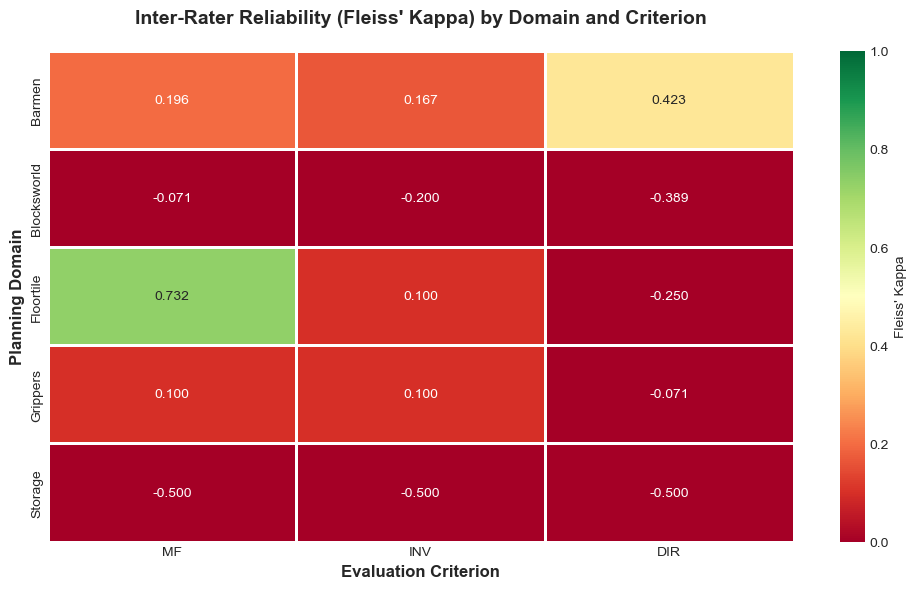


 Heatmap generated!
Interpretation: Green = High agreement, Yellow = Moderate, Red = Low agreement


In [8]:
# Create heatmap for domain-stratified Kappa
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for heatmap
heatmap_data = []
for domain in domains:
    row = [domain_results[domain][crit]['kappa'] for crit in ['MF', 'INV', 'DIR']]
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, 
                          index=[d.capitalize() for d in domains],
                          columns=['MF', 'INV', 'DIR'])

# Create heatmap
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=0.5, vmin=0, vmax=1, 
            cbar_kws={'label': "Fleiss' Kappa"},
            linewidths=1, linecolor='white')

plt.title("Inter-Rater Reliability (Fleiss' Kappa) by Domain and Criterion", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Evaluation Criterion', fontsize=12, fontweight='bold')
plt.ylabel('Planning Domain', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Heatmap generated!")
print("Interpretation: Green = High agreement, Yellow = Moderate, Red = Low agreement")

## Step 8: Visualization - Overall Kappa Bar Chart

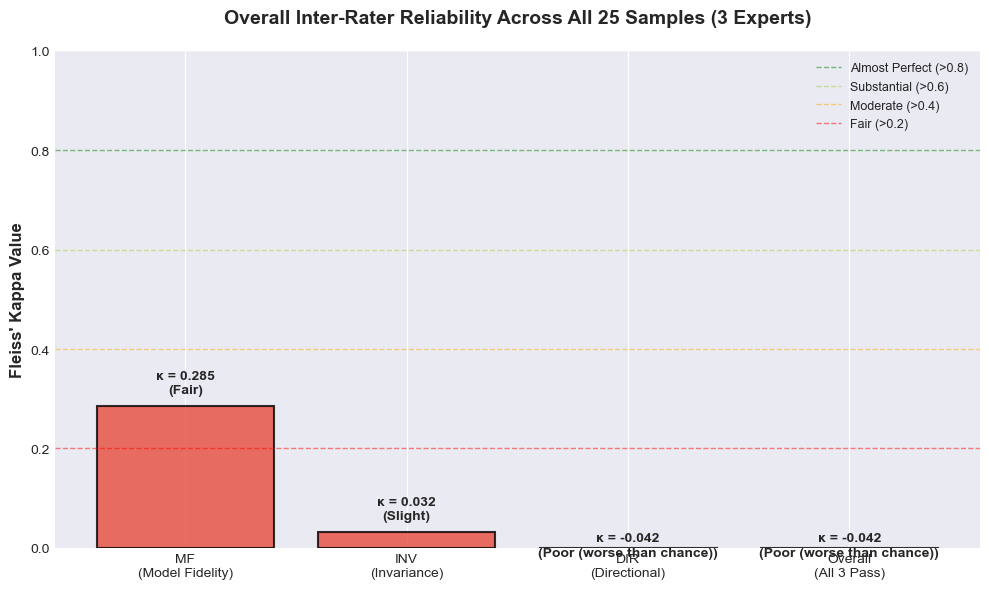


 Bar chart generated!


In [9]:
# Create bar chart for overall Kappa
fig, ax = plt.subplots(figsize=(10, 6))

criteria_labels = ['MF\n(Model Fidelity)', 'INV\n(Invariance)', 
                   'DIR\n(Directional)', 'Overall\n(All 3 Pass)']
kappa_values = [overall_results[c]['kappa'] for c in criteria]
colors = ['#2ecc71' if k > 0.6 else '#f39c12' if k > 0.4 else '#e74c3c' for k in kappa_values]

bars = ax.bar(criteria_labels, kappa_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, kappa) in enumerate(zip(bars, kappa_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'κ = {kappa:.3f}\n({overall_results[criteria[i]]["interpretation"]})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add interpretation guidelines
ax.axhline(y=0.8, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Almost Perfect (>0.8)')
ax.axhline(y=0.6, color='yellowgreen', linestyle='--', linewidth=1, alpha=0.5, label='Substantial (>0.6)')
ax.axhline(y=0.4, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Moderate (>0.4)')
ax.axhline(y=0.2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Fair (>0.2)')

ax.set_ylabel("Fleiss' Kappa Value", fontsize=12, fontweight='bold')
ax.set_title("Overall Inter-Rater Reliability Across All 25 Samples (3 Experts)", 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Bar chart generated!")

## Step 9: Pairwise Kappa Comparison

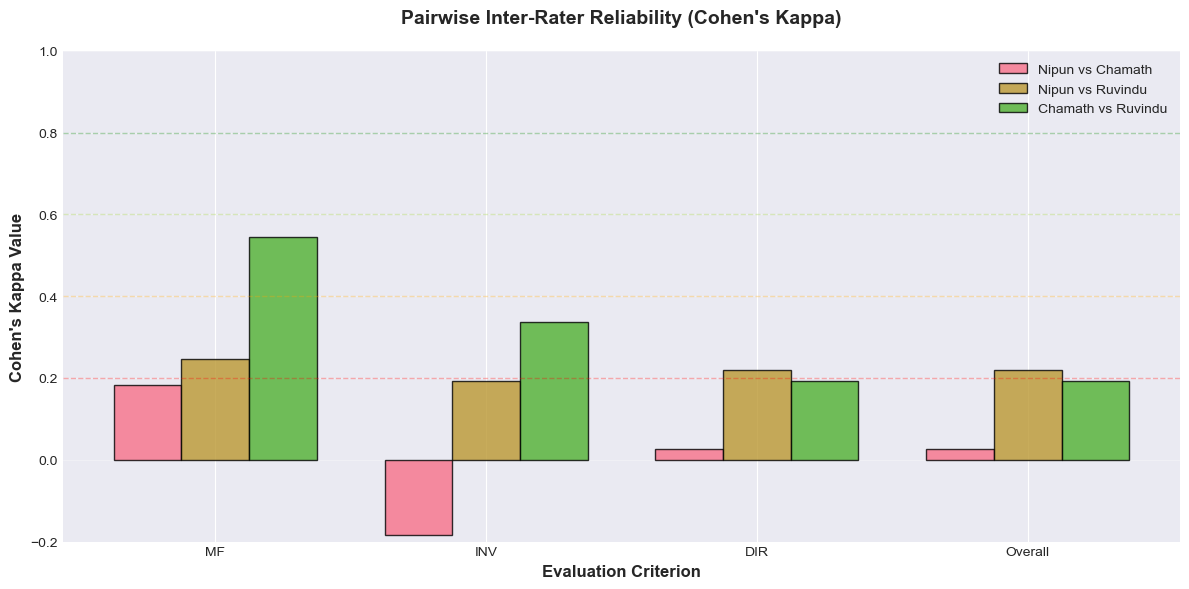


 Pairwise comparison chart generated!


In [10]:
# Create grouped bar chart for pairwise Kappa
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(criteria))
width = 0.25

pairs_list = list(pairwise_results.keys())
for i, pair in enumerate(pairs_list):
    kappas = [pairwise_results[pair][c]['kappa'] for c in criteria]
    offset = (i - 1) * width
    ax.bar(x + offset, kappas, width, label=pair, alpha=0.8, edgecolor='black', linewidth=1)

ax.set_xlabel('Evaluation Criterion', fontsize=12, fontweight='bold')
ax.set_ylabel("Cohen's Kappa Value", fontsize=12, fontweight='bold')
ax.set_title("Pairwise Inter-Rater Reliability (Cohen's Kappa)", 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(['MF', 'INV', 'DIR', 'Overall'])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.2, 1.0)

# Add interpretation lines
ax.axhline(y=0.8, color='green', linestyle='--', linewidth=1, alpha=0.3)
ax.axhline(y=0.6, color='yellowgreen', linestyle='--', linewidth=1, alpha=0.3)
ax.axhline(y=0.4, color='orange', linestyle='--', linewidth=1, alpha=0.3)
ax.axhline(y=0.2, color='red', linestyle='--', linewidth=1, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Pairwise comparison chart generated!")

## Step 10: Summary Report

In [11]:
# Generate comprehensive summary report
print("\n" + "=" * 70)
print(" COMPREHENSIVE INTER-RATER RELIABILITY REPORT")
print("=" * 70)

print("\n KEY FINDINGS:")
print("-" * 70)

# Finding 1: Overall agreement
print("\n1. OVERALL AGREEMENT (Fleiss' Kappa):")
for criterion in criteria:
    result = overall_results[criterion]
    sig = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "ns"
    print(f"   • {criterion}: κ = {result['kappa']:.3f} ({result['interpretation']}) {sig}")

# Finding 2: Identify most/least agreed criterion
kappa_by_criterion = {c: overall_results[c]['kappa'] for c in ['MF', 'INV', 'DIR']}
most_agreed = max(kappa_by_criterion, key=kappa_by_criterion.get)
least_agreed = min(kappa_by_criterion, key=kappa_by_criterion.get)

print(f"\n    Highest agreement: {most_agreed} (κ = {kappa_by_criterion[most_agreed]:.3f})")
print(f"     Lowest agreement: {least_agreed} (κ = {kappa_by_criterion[least_agreed]:.3f})")

# Finding 3: Domain patterns
print("\n2. DOMAIN-SPECIFIC PATTERNS:")
for domain in domains:
    avg_kappa = np.mean([domain_results[domain][c]['kappa'] for c in ['MF', 'INV', 'DIR']])
    print(f"   • {domain.capitalize()}: Average κ = {avg_kappa:.3f}")
    
    # Show which criterion is most problematic
    worst_criterion = min(['MF', 'INV', 'DIR'], 
                         key=lambda c: domain_results[domain][c]['kappa'])
    worst_kappa = domain_results[domain][worst_criterion]['kappa']
    print(f"     └─ Lowest: {worst_criterion} (κ = {worst_kappa:.3f})")

# Finding 4: Pairwise patterns
print("\n3. EXPERT PAIR AGREEMENTS:")
avg_pairwise = {}
for pair in pairwise_results:
    avg_kappa = np.mean([pairwise_results[pair][c]['kappa'] for c in criteria])
    avg_pairwise[pair] = avg_kappa
    print(f"   • {pair}: Average κ = {avg_kappa:.3f}")

most_aligned_pair = max(avg_pairwise, key=avg_pairwise.get)
least_aligned_pair = min(avg_pairwise, key=avg_pairwise.get)

print(f"\n    Most aligned experts: {most_aligned_pair} (κ = {avg_pairwise[most_aligned_pair]:.3f})")
print(f"     Least aligned experts: {least_aligned_pair} (κ = {avg_pairwise[least_aligned_pair]:.3f})")

# Finding 5: Implications
print("\n4. IMPLICATIONS FOR RESEARCH:")
print("-" * 70)

if overall_results['DIR']['kappa'] < 0.4:
    print("     DIR (Directional) shows low agreement - criterion may need clearer definition")
    
storage_avg = np.mean([domain_results['storage'][c]['kappa'] for c in ['MF', 'INV', 'DIR']])
if storage_avg < 0.3:
    print("     Storage domain shows poor agreement - indicates evaluation difficulty")
    print("      This validates the 'Adaptive Robustness' theme from thematic analysis")
    
if avg_pairwise['Chamath vs Ruvindu'] > 0.5 and avg_pairwise['Nipun vs Chamath'] < avg_pairwise['Chamath vs Ruvindu']:
    print("    Chamath and Ruvindu show stronger alignment than with Nipun")
    print("      Suggests different evaluation philosophy or expertise level")

print("\n5. RECOMMENDATION FOR PAPER:")
print("-" * 70)
print("""
   Include this analysis in your Methods and Results sections:
   
   METHODS: "We assessed inter-rater reliability using Fleiss' Kappa (Fleiss, 1971)
            for three domain experts evaluating 25 planning problems across three
            quality criteria (MF, INV, DIR). We conducted overall, domain-stratified,
            and pairwise analyses to identify agreement patterns."
   
   RESULTS: Report the Kappa values, interpretations, and connect low-agreement
            domains (e.g., Storage) to your thematic analysis findings about
            structural ambiguity and evaluation challenges.
""")

print("\n" + "=" * 70)
print(" ANALYSIS COMPLETE!")
print("=" * 70)


 COMPREHENSIVE INTER-RATER RELIABILITY REPORT

 KEY FINDINGS:
----------------------------------------------------------------------

1. OVERALL AGREEMENT (Fleiss' Kappa):
   • MF: κ = 0.285 (Fair) ***
   • INV: κ = 0.032 (Slight) ns
   • DIR: κ = -0.042 (Poor (worse than chance)) ns
   • Overall: κ = -0.042 (Poor (worse than chance)) ns

    Highest agreement: MF (κ = 0.285)
     Lowest agreement: DIR (κ = -0.042)

2. DOMAIN-SPECIFIC PATTERNS:
   • Barmen: Average κ = 0.262
     └─ Lowest: INV (κ = 0.167)
   • Blocksworld: Average κ = -0.220
     └─ Lowest: DIR (κ = -0.389)
   • Floortile: Average κ = 0.194
     └─ Lowest: DIR (κ = -0.250)
   • Grippers: Average κ = 0.043
     └─ Lowest: DIR (κ = -0.071)
   • Storage: Average κ = -0.500
     └─ Lowest: MF (κ = -0.500)

3. EXPERT PAIR AGREEMENTS:
   • Nipun vs Chamath: Average κ = 0.013
   • Nipun vs Ruvindu: Average κ = 0.219
   • Chamath vs Ruvindu: Average κ = 0.318

    Most aligned experts: Chamath vs Ruvindu (κ = 0.318)
     Lea